In [150]:
# Import libraries
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from pycoingecko import CoinGeckoAPI
import joblib

import matplotlib.pyplot as plt

### Strategy description
Implementation of the C-3 factor model using linear regression

In [151]:
# define ticker symbol for bitcoin
ticker = 'BTC-USD'

# define the time period
start_date = '2015-02-25'  
end_date = '2024-08-19'

# create ticker object
btc_ticker = yf.Ticker(ticker)

# get weekly OHLCV data
btc_data = btc_ticker.history(interval='1wk', start=start_date, end=end_date)

# reset index to have 'Date' as a column
btc_data.reset_index(inplace=True)

# make a copy of the data for further processing
df = btc_data.copy()

# look at the first few rows of the data
btc_data.head()


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2015-02-23 00:00:00+00:00,238.889999,261.660004,234.257004,260.201996,108292500,0.0,0.0
1,2015-03-02 00:00:00+00:00,260.356995,285.795990,258.312988,274.354004,242425100,0.0,0.0
2,2015-03-09 00:00:00+00:00,274.812012,300.044006,273.893005,286.393005,259502000,0.0,0.0
3,2015-03-16 00:00:00+00:00,285.684998,294.112000,248.636002,267.959991,206778200,0.0,0.0
4,2015-03-23 00:00:00+00:00,267.894989,277.296997,236.514999,242.712997,179497700,0.0,0.0


In [152]:
# get market cap data 
btc_cap = pd.read_csv('Bitcoin_marketcap.csv', sep=";")
btc_cap['timeClose'] = pd.to_datetime(btc_cap['timeClose'], utc=True)
btc_cap["week_end"] = btc_cap["timeClose"].dt.floor("D")          
btc_cap = btc_cap[(btc_cap["timeClose"] >= start_date) & (btc_cap["timeClose"] <= end_date)]

# keep the right column name
btc_cap = btc_cap[["week_end", "marketCap"]].drop_duplicates("week_end")

# shift to align with next week's return prediction
btc_cap['marketCap'] = btc_cap['marketCap'].shift(1)  

# yfinance dataframe to utc datetime
df["Date"] = pd.to_datetime(df["Date"], utc=True)

# yfinance weekly Date is Monday -> map to same Sunday week_end
df["week_end"] = (df["Date"] + pd.Timedelta(days=6)).dt.floor("D")

# --- merge on week_end ---
df = df.merge(btc_cap, on="week_end", how="left")

df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,week_end,marketCap
0,2015-02-23 00:00:00+00:00,238.889999,261.660004,234.257004,260.201996,108292500,0.0,0.0,2015-03-01 00:00:00+00:00,NaN
1,2015-03-02 00:00:00+00:00,260.356995,285.795990,258.312988,274.354004,242425100,0.0,0.0,2015-03-08 00:00:00+00:00,NaN
2,2015-03-09 00:00:00+00:00,274.812012,300.044006,273.893005,286.393005,259502000,0.0,0.0,2015-03-15 00:00:00+00:00,NaN
3,2015-03-16 00:00:00+00:00,285.684998,294.112000,248.636002,267.959991,206778200,0.0,0.0,2015-03-22 00:00:00+00:00,NaN
4,2015-03-23 00:00:00+00:00,267.894989,277.296997,236.514999,242.712997,179497700,0.0,0.0,2015-03-29 00:00:00+00:00,NaN


In [153]:
# define weekly returns based on closing prices
df['ret'] = df['Close'].pct_change()

# Define CMKT Proxy as the weekly return of BTC-USD
df['cmkt'] = df['ret']

# Calculate CMOM over a 2-week period
df['cmom'] = df['ret'].rolling(window=2).sum()

# Define mcap-cmom interaction term
# Define mcap-cmkt interaction term
df['csize'] = np.log(df['marketCap'])
df['csize_cmom'] = df['csize'] * df['cmom']
df['csize_cmkt'] = df['csize'] * df['cmkt']

# Higher Order terms
df['cmkt_2'] = df['cmkt'] ** 2
df['cmom_3'] = df['cmom'] ** 3

# define next week's return as the target variable
df['target_ret'] = df['ret'].shift(-1)

# Drop rows with NaN values
df.dropna(inplace=True)

# check the dataframe
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,week_end,marketCap,ret,cmkt,cmom,csize,csize_cmom,csize_cmkt,cmkt_2,cmom_3,target_ret
170,2018-05-28 00:00:00+00:00,7371.310059,7754.890137,7090.680176,7720.250000,35465450496,0.0,0.0,2018-06-03 00:00:00+00:00,1.159483e+11,0.047777,0.047777,-0.086723,25.476410,-2.209390,1.217181,0.002283,-0.000652,-0.121010
171,2018-06-04 00:00:00+00:00,7722.529785,7753.819824,6709.069824,6786.020020,33010609408,0.0,0.0,2018-06-10 00:00:00+00:00,1.111348e+11,-0.121010,-0.121010,-0.073234,25.434009,-1.862623,-3.077778,0.014643,-0.000393,-0.042256
172,2018-06-11 00:00:00+00:00,6799.290039,6910.180176,6285.629883,6499.270020,29844289792,0.0,0.0,2018-06-17 00:00:00+00:00,1.056466e+11,-0.042256,-0.042256,-0.163266,25.383365,-4.144249,-1.072599,0.001786,-0.004352,-0.050166
173,2018-06-18 00:00:00+00:00,6510.069824,6822.500000,5826.410156,6173.229980,28592079872,0.0,0.0,2018-06-24 00:00:00+00:00,1.093660e+11,-0.050166,-0.050166,-0.092422,25.417966,-2.349170,-1.275109,0.002517,-0.000789,0.034437
174,2018-06-25 00:00:00+00:00,6171.970215,6465.509766,5835.750000,6385.819824,28842940160,0.0,0.0,2018-07-01 00:00:00+00:00,1.160970e+11,0.034437,0.034437,-0.015728,25.477692,-0.400720,0.877385,0.001186,-0.000004,0.060769


In [154]:
# Extract features and labels
features = ['cmkt', 'cmom', 'csize', 'cmkt_2', 'cmom_3', 'csize_cmkt']
X = df[features]
y = df['target_ret']  # Predicting next week's return
X.shape, y.shape, features

((324, 6), (324,), ['cmkt', 'cmom', 'csize', 'cmkt_2', 'cmom_3', 'csize_cmkt'])

In [155]:
# define the ridge regression model
model = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", Ridge(alpha=1.0))
])

# split the data into training and testing sets (85% train, 15% test)
split = int(len(X) * 0.85)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

model.fit(X_train, y_train)
pred = model.predict(X_test)
df.loc[X_test.index, "pred"] = model.predict(X_test)
df["signal"] = np.sign(df["pred"])
df["strat_ret"] = df["signal"].shift(1) * df["ret"]


In [156]:
print("Correlation(pred, y):", np.corrcoef(pred, y_test)[0,1])

Correlation(pred, y): 0.15772353210438478


In [166]:
np.mean(y_test[pred > 0]) - np.mean(y_test[pred < 0])

np.float64(-0.0007947323692237863)

In [157]:
df.loc[X_test.index, "pred"] = model.predict(X_test)
df["signal"] = np.sign(df["pred"])  # -1 short, +1 long

# Toy strategy returns (no fees/slippage)
df["strat_ret"] = df["signal"].shift(1) * df["ret"]

fee = 0.001  # 10 bps per trade
turnover = df["signal"].diff().abs().fillna(0)
df["strat_ret_net"] = df["strat_ret"] - fee * turnover


(df[["ret","pred","signal","strat_ret","strat_ret_net"]].dropna()).tail(10)


,ret,pred,signal,strat_ret,strat_ret_net
484,0.027990,0.014095,1.0,0.027990,0.027990
485,-0.043202,0.003344,1.0,-0.043202,-0.043202
486,-0.051895,-0.001167,-1.0,-0.051895,-0.053895
487,-0.007953,0.003775,1.0,0.007953,0.005953
488,-0.108956,-0.003097,-1.0,-0.108956,-0.110956
489,0.088429,0.025107,1.0,-0.088429,-0.090429
490,0.121188,0.040725,1.0,0.121188,0.121188
491,0.001487,0.014021,1.0,0.001487,0.001487
492,-0.148542,-0.001856,-1.0,-0.148542,-0.150542
493,0.010367,0.003753,1.0,-0.010367,-0.012367


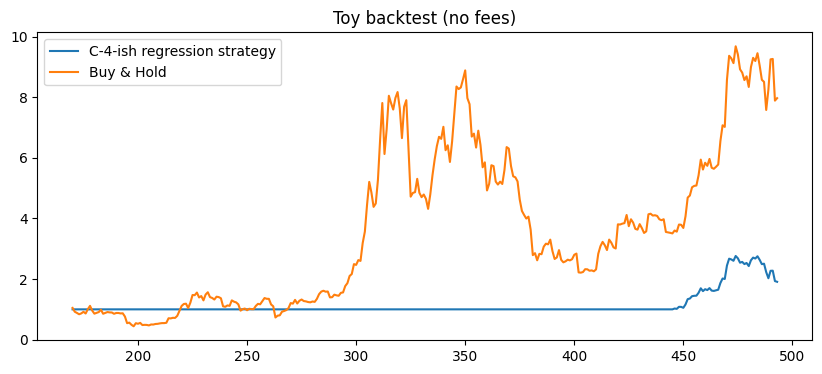

In [158]:
import matplotlib.pyplot as plt

equity = (1 + df["strat_ret_net"].fillna(0)).cumprod()
buyhold = (1 + df["ret"].fillna(0)).cumprod()

plt.figure(figsize=(10,4))
plt.plot(equity, label="C-4-ish regression strategy")
plt.plot(buyhold, label="Buy & Hold")
plt.legend()
plt.title("Toy backtest (no fees)")
plt.show()


In [159]:
# Information Ratio Calculation
# Information Ratio = Mean(strategy returns) / StdDev(strategy returns)
df.loc[X_test.index, "strat_ret_net"].mean() / df.loc[X_test.index, "strat_ret_net"].std()

np.float64(0.23176995572684111)

In [160]:
# check: does marketCap correlate more with NEXT week's return than this week's?
corr_next = df["marketCap"].corr(df["ret"].shift(-1))
corr_same = df["marketCap"].corr(df["ret"])

corr_next, corr_same

(np.float64(0.04880390904061534), np.float64(0.06517618848186978))

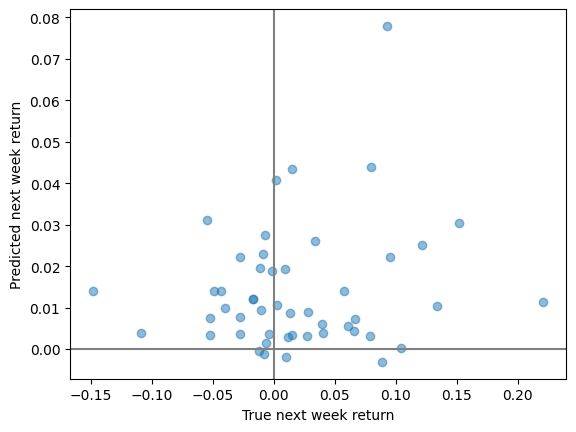

In [161]:
# Plot true vs predicted returns
plt.scatter(y_test, pred, alpha=0.5)
plt.xlabel("True next week return")
plt.ylabel("Predicted next week return")
plt.axhline(0, color="gray")
plt.axvline(0, color="gray")
plt.show()

In [163]:
# prediction accuracy
accuracy = (np.sign(pred) == np.sign(y_test)).mean()
accuracy

np.float64(0.5510204081632653)

In [162]:
# export model
joblib.dump(model, 'lin_reg_model.joblib')

['lin_reg_model.joblib']